## Neural Network Predicting Continuous Outputs without Embeddings

### By: Samuel Dominguez

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import keras_tuner as kt

import tensorflow as tf

import matplotlib.pyplot as plt

In [20]:
# 2. NumPy
np.random.seed(42)

# 3. TensorFlow
tf.random.set_seed(42)

In [21]:
# Load data
df = pd.read_csv("../data/processed/processed_plays.csv")
df.head()

,down,yardsToGo,absoluteYardlineNumber,quarter,playAction,qbSneak,pff_runPassOption,yardsGained,secondsRemainingInQuarter,leftReceivers,...,passCoverage_Cover_3_Seam,passCoverage_Cover_6_Right,passCoverage_Goal_Line,passCoverage_Miscellaneous,passCoverage_Prevent,passCoverage_Quarters,passCoverage_Red_Zone,manZone_Man,manZone_Other,manZone_Zone
0,1,10,21,3,0,0,0,9,114,3,...,0,0,0,0,0,0,0,0,0,1
1,1,10,8,4,0,0,0,4,133,3,...,0,0,0,0,0,1,0,0,0,1
2,3,12,20,4,0,0,0,6,120,2,...,0,0,0,0,0,1,0,0,0,1
3,2,10,23,1,0,0,0,4,568,2,...,0,0,0,0,0,1,0,0,0,1
4,2,8,27,3,1,0,0,-1,136,3,...,0,0,0,0,0,0,0,1,0,0


In [22]:
X = df.drop('yardsGained', axis=1)
Y = df.yardsGained

In [23]:
Y

0         9
1         4
2         6
3         4
4        -1
         ..
15906     0
15907     0
15908    10
15909     0
15910    34
Name: yardsGained, Length: 15911, dtype: int64

In [24]:
# Partition data into 3 sets with a split of [.6, .2, .2]
_X_train, X_test, _Y_train, Y_test = train_test_split(X, Y, train_size=0.8, shuffle=True, random_state=42)
# .6 is 75% of .8 (.6 + .2)
X_train, X_val, Y_train, Y_val = train_test_split(_X_train, _Y_train, train_size=0.75, shuffle=True, random_state=42)

# Output shapes
print("X_train", X_train.shape)
print("Y_train", Y_train.shape)

print("X_val", X_val.shape)
print("Y_val", Y_val.shape)

print("X_test", X_test.shape)
print("Y_test", Y_test.shape)

X_train (9546, 65)
Y_train (9546,)
X_val (3182, 65)
Y_val (3182,)
X_test (3183, 65)
Y_test (3183,)


In [25]:
print(len(df) * 0.6)
print(len(X_train))

print(len(df) * 0.2)
print(len(X_val))

print(len(df) * 0.2)
print(len(X_test))

9546.6
9546
3182.2000000000003
3182
3182.2000000000003
3183


In [26]:
# Normalize X train, X val, and X test
def normalize(X):
    means = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - means) / std

non_encoded_variables = ['down', 'yardsToGo', 'absoluteYardlineNumber', 'quarter', 'playAction', 'qbSneak', 'secondsRemainingInQuarter', 'leftReceivers', 'rightReceivers']
encoded_variables = ['pff_runPassOption', 'offFormation_EMPTY', 'offFormation_I_FORM', 'offFormation_JUMBO',
       'offFormation_PISTOL', 'offFormation_SHOTGUN',
       'offFormation_SINGLEBACK', 'offFormation_WILDCAT', 'dropbackType_DESIGNED_ROLLOUT_LEFT',
       'dropbackType_DESIGNED_ROLLOUT_RIGHT', 'dropbackType_DESIGNED_RUN',
       'dropbackType_QB_SNEAK', 'dropbackType_SCRAMBLE',
       'dropbackType_SCRAMBLE_ROLLOUT_LEFT',
       'dropbackType_SCRAMBLE_ROLLOUT_RIGHT', 'dropbackType_TRADITIONAL',
       'dropbackType_UNKNOWN', 'rushLocation_INSIDE_LEFT',
       'rushLocation_INSIDE_RIGHT', 'rushLocation_NONE',
       'rushLocation_OUTSIDE_LEFT', 'rushLocation_OUTSIDE_RIGHT',
       'rushConcept_COUNTER', 'rushConcept_DRAW', 'rushConcept_FB_RUN',
       'rushConcept_INSIDE_ZONE', 'rushConcept_MAN', 'rushConcept_NONE',
       'rushConcept_OTHER', 'rushConcept_OUTSIDE_ZONE', 'rushConcept_POWER',
       'rushConcept_PULL_LEAD', 'rushConcept_SNEAK', 'rushConcept_TRAP',
       'rushConcept_TRICK', 'passCoverage_2_Man', 'passCoverage_Bracket',
       'passCoverage_Cover_6_Left', 'passCoverage_Cover_0',
       'passCoverage_Cover_1', 'passCoverage_Cover_1_Double',
       'passCoverage_Cover_2', 'passCoverage_Cover_3',
       'passCoverage_Cover_3_Cloud_Left', 'passCoverage_Cover_3_Cloud_Right',
       'passCoverage_Cover_3_Double_Cloud', 'passCoverage_Cover_3_Seam',
       'passCoverage_Cover_6_Right', 'passCoverage_Goal_Line',
       'passCoverage_Miscellaneous', 'passCoverage_Prevent',
       'passCoverage_Quarters', 'passCoverage_Red_Zone', 'manZone_Man',
       'manZone_Other', 'manZone_Zone']

X_train = pd.concat([normalize(X_train[non_encoded_variables]), X_train[encoded_variables]], axis=1)
X_val = pd.concat([normalize(X_val[non_encoded_variables]), X_val[encoded_variables]], axis=1)
X_test = pd.concat([normalize(X_test[non_encoded_variables]), X_test[encoded_variables]], axis=1)

In [27]:
X_train

,down,yardsToGo,absoluteYardlineNumber,quarter,playAction,qbSneak,secondsRemainingInQuarter,leftReceivers,rightReceivers,pff_runPassOption,...,passCoverage_Cover_3_Seam,passCoverage_Cover_6_Right,passCoverage_Goal_Line,passCoverage_Miscellaneous,passCoverage_Prevent,passCoverage_Quarters,passCoverage_Red_Zone,manZone_Man,manZone_Other,manZone_Zone
15763,0.231820,-0.882628,0.925524,0.383966,-0.457464,-0.088388,0.041935,-0.871392,1.028462,0,...,0,0,0,0,0,0,0,0,0,1
4947,-0.973491,0.389732,0.636732,-1.379486,-0.457464,-0.088388,1.118153,0.993699,-0.945342,0,...,0,0,0,0,0,0,0,0,0,1
10302,2.642441,0.135260,-1.714859,1.265692,-0.457464,-0.088388,-1.316326,0.993699,-0.945342,0,...,0,0,0,0,0,0,0,0,1,0
3150,0.231820,-0.373684,-1.549835,-0.497760,-0.457464,-0.088388,1.455863,-0.871392,-0.945342,1,...,0,0,0,0,0,1,0,0,0,1
14143,-0.973491,0.389732,-1.549835,-1.379486,2.185967,-0.088388,0.476133,-0.871392,1.028462,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13584,0.231820,-1.900515,1.998179,1.265692,2.185967,-0.088388,-1.527859,0.993699,-0.945342,0,...,0,0,0,0,0,0,0,1,0,0
2262,-0.973491,0.389732,0.595476,-0.497760,-0.457464,-0.088388,0.620866,-0.871392,1.028462,1,...,0,0,0,0,0,0,0,0,0,1
6984,1.437130,-1.137100,-1.673603,0.383966,-0.457464,-0.088388,-1.130771,0.993699,-0.945342,0,...,0,0,0,0,0,0,0,1,0,0
651,1.437130,-0.882628,-0.765971,-0.497760,-0.457464,-0.088388,-1.331171,0.993699,-0.945342,0,...,0,0,0,0,0,1,0,0,0,1


In [ ]:
def build_model(hidden_layer_sizes=[],
                activation='relu',
                optimizer='Adam',
                learning_rate=0.01):
    tf.keras.backend.clear_session()

    # Initialize sequential model
    model = tf.keras.Sequential()
    
    model.add(
        tf.keras.layers.Input(shape=(65,), name='input')
    )

    # Add new hidden layers of a given size with the specified activation
    for index, hidden_layer_size in enumerate(hidden_layer_sizes):
        model.add(
            tf.keras.layers.Dense(units=hidden_layer_size, activation=activation, name=f'hidden_layer_{index + 1}')
        )

    # Output layer
    model.add(
        tf.keras.layers.Dense(units=1, activation=None, name='output')
    )

    # Initialize optimizer based on parameter
    model_optimizer = None
    if optimizer == 'SGD':
        model_optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == 'Adam':
        model_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        print(f'Invalid optimizer: {optimizer}')
        return None

    # Compile model with specified metric
    model.compile(
        optimizer=model_optimizer,
        loss='mse',
        metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse'),
             tf.keras.metrics.MeanAbsoluteError(name='mae')]
    )

    return model

In [29]:
model = build_model([16], learning_rate=0.001, optimizer='Adam')

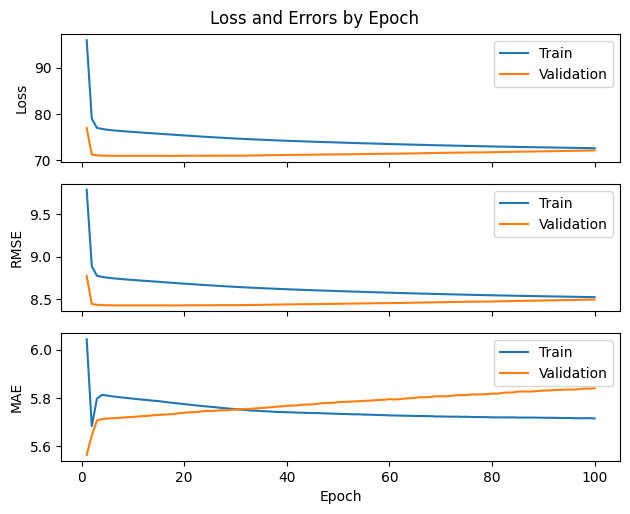

In [30]:
def fit_and_plot_model(model_):

    fitting_history = model_.fit(
        x=X_train,
        y=Y_train,
        epochs=100,
        batch_size=64,
        validation_data=(X_val, Y_val),
        verbose=0
    )

    # # 4. Generate (1,3) plot
    fig, axes = plt.subplots(3, 1, sharex=True)

    # Plot losses by epoch
    losses = fitting_history.history.get('loss')
    val_losses = fitting_history.history.get('val_loss')

    axes[0].plot(range(1, len(losses) + 1), losses, label='Train')
    axes[0].plot(range(1, len(val_losses) + 1), val_losses, label='Validation')
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Plot RMSE by epoch
    rmse = fitting_history.history.get('rmse')
    val_rsme = fitting_history.history.get('val_rmse')

    axes[1].plot(range(1, len(rmse) + 1), rmse, label='Train')
    axes[1].plot(range(1, len(val_rsme) + 1), val_rsme, label='Validation')
    axes[1].set_ylabel("RMSE")
    axes[1].legend()

    # Plot MAE by epoch
    mae = fitting_history.history.get('mae')
    val_mae = fitting_history.history.get('val_mae')

    axes[2].plot(range(1, len(rmse) + 1), mae, label='Train')
    axes[2].plot(range(1, len(val_mae) + 1), val_mae, label='Validation')
    axes[2].set_ylabel("MAE")
    axes[2].legend()

    # General figure settings
    fig.tight_layout()
    fig.suptitle("Loss and Errors by Epoch", y=1.02)
    axes[-1].set_xlabel('Epoch')
    plt.legend()
    plt.show()

fit_and_plot_model(model)

In [31]:
print(model.predict(X_test)[4])

print(Y_test.iloc[4])

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 358us/step
[7.8686385]
5


In [ ]:
def hypertuned_model(hp):
    # Initialize sequential model
    model = tf.keras.Sequential()

    model.add(
        tf.keras.layers.Input(shape=(65,), name='input')
    )

    # Tune the number of layers.
    for i in range(hp.Int("num_layers", 1, 4)):
        model.add(
            tf.keras.layers.Dense(
                units=hp.Int(f"units_{i}", min_value=16, max_value=512, step=32),
                activation=hp.Choice("activation", ["relu", "tanh"]),
            )
        )
        if hp.Boolean("dropout"):
            model.add(tf.keras.layers.Dropout(rate=hp.Float('dropout_rate', min_value=0, max_value=1)))

    model.add(tf.keras.layers.Dense(1))

    learning_rate = hp.Float("lr", min_value=1e-4, max_value=1e-2)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse'),
             tf.keras.metrics.MeanAbsoluteError(name='mae')]
    )

    return model

In [33]:
tuner = kt.Hyperband(
    hypermodel=hypertuned_model,
    objective="val_mae",
    overwrite=True,
    directory="tuning",
    project_name="tuning_dominguez",
)

In [16]:
tuner.search(
    x=X_train,
    y=Y_train,
    epochs=50,
    validation_data=(X_val, Y_val),
    verbose=1
)

Trial 254 Complete [00h 00m 24s]
val_mae: 5.870282173156738

Best val_mae So Far: 5.493706703186035
Total elapsed time: 00h 26m 48s


In [17]:
best_model = tuner.get_best_models()[0]
best_model.summary()

/Users/samdominguez/School/Berkeley/Summer2025/DATASCI207/FinalProject/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 400)            │        26,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 240)            │        96,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 240)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 304)            │        73,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 304)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 80)             │        24,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,385 (860.88 KB)

 Trainable params: 220,385 (860.88 KB)

 Non-trainable params: 0 (0.00 B)

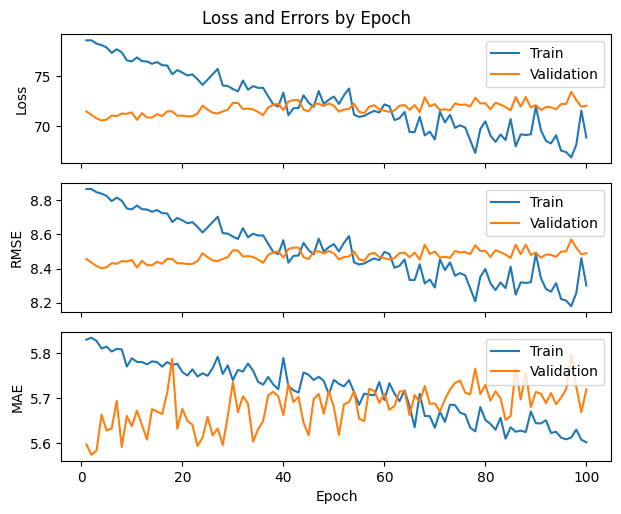

In [18]:
fit_and_plot_model(best_model)